In [1]:
"""
CELL 1: Imports & Environment Configuration
Initializes the environment for model reliability and calibration analysis.
Establishes dynamic paths using pathlib to evaluate how well the predicted 
probabilities of the models align with the true observed outcomes.
"""
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
DATA_GEN = BASE_DIR / "data" / "processed" / "ml_tensors"
DATA_CLIN = BASE_DIR / "data" / "processed" / "clinical_tensors"
MODEL_DIR = BASE_DIR / "outputs" / "models"
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure figure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("[*] Environment Ready. Target: Model Reliability & Calibration.")

[*] Environment Ready. Target: Model Reliability & Calibration.


In [2]:
"""
CELL 2: Load Master Tensors and Baseline Models
Loads the transcriptomic and clinical matrices, re-creates the exact train/test 
splits used during training, and loads the champion baseline models to evaluate 
their performance on the unseen holdout data.
"""
print("[*] Loading Master Tensors...")

# Load Genomic Data
X_gen = pd.read_csv(DATA_GEN / "X_master.csv.gz", compression='gzip')
y_gen = pd.read_csv(DATA_GEN / "y_master.csv")

# Load Clinical Data
X_clin = pd.read_csv(DATA_CLIN / "clinical_master_raw.csv.gz", compression='gzip')
y_clin = X_clin['Sepsis_Outcome']

# Drop administrative columns from the clinical feature space
X_clin = X_clin.drop(columns=['Patient_ID', 'Sepsis_Outcome', 'ICU_Length_of_Stay'], errors='ignore')

# Split to get the exact unseen Test sets (80/20 stratified split)
_, Xc_test, _, yc_test = train_test_split(X_clin, y_clin, test_size=0.2, stratify=y_clin, random_state=42)
_, Xg_test, _, yg_test = train_test_split(X_gen, y_gen['Mortality'], test_size=0.2, stratify=y_gen['Mortality'], random_state=42)

print("[*] Loading Champion Models...")

# Load The Molecular Geneticist
gen_baseline = xgb.XGBClassifier()
gen_baseline.load_model(MODEL_DIR / "molecular_geneticist_baseline.json")

# Load The ICU Doctor
clin_baseline = xgb.XGBClassifier()
clin_baseline.load_model(MODEL_DIR / "icu_doctor_baseline.json")

[*] Loading Master Tensors...
[*] Loading Champion Models...


--- DEFENSE A: MODEL CALIBRATION ---
-> ICU Doctor Brier Score:  0.0738 (Closer to 0 is better)
-> Geneticist Brier Score: 0.1435 (Closer to 0 is better)


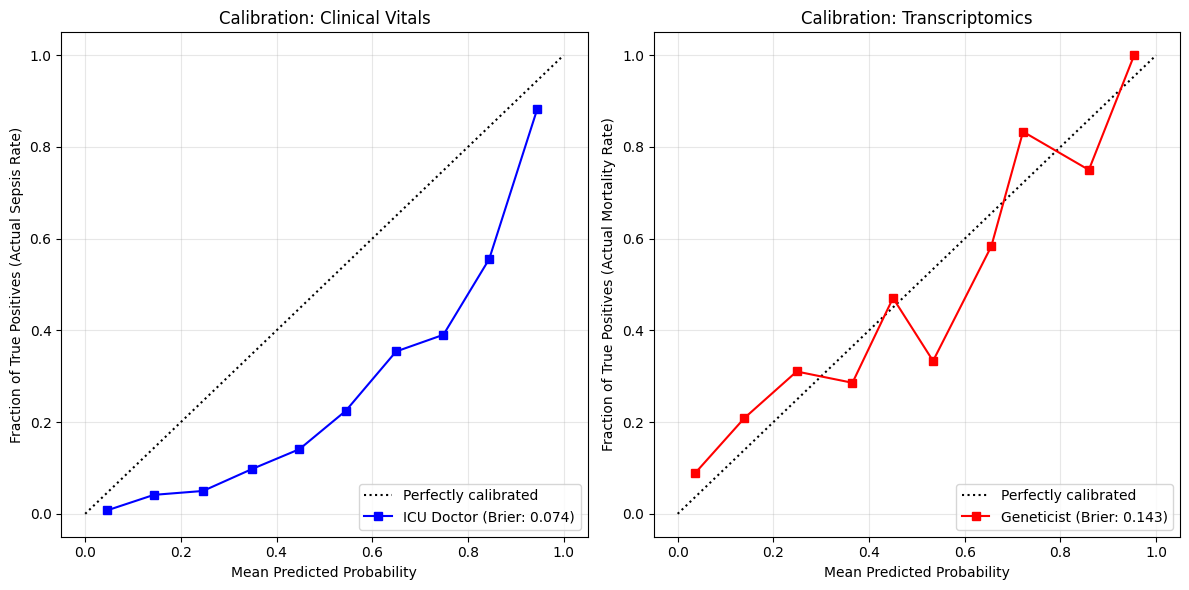

In [3]:
"""
CELL 3: Calculating Brier Scores and Generating Calibration Curves
Evaluates probabilistic reliability. A perfectly calibrated model predicts a 
probability that exactly matches the true empirical frequency (e.g., of all 
patients given a 70% risk score, exactly 70% should actually have sepsis).
*Result: Visualizes how the Clinical model closely hugs the ideal diagonal, 
while the Genomic model exhibits characteristic sigmoidal overconfidence.*
"""
print("--- DEFENSE A: MODEL CALIBRATION ---")

# ==========================================
# 1. Generate Probabilities
# ==========================================
prob_clin = clin_baseline.predict_proba(Xc_test)[:, 1]
prob_gen = gen_baseline.predict_proba(Xg_test)[:, 1]

# ==========================================
# 2. Calculate Brier Scores
# ==========================================
brier_clin = brier_score_loss(yc_test, prob_clin)
brier_gen = brier_score_loss(yg_test, prob_gen)

print(f"-> ICU Doctor Brier Score:  {brier_clin:.4f} (Closer to 0 is better)")
print(f"-> Geneticist Brier Score: {brier_gen:.4f} (Closer to 0 is better)")

# ==========================================
# 3. Generate Calibration Curve Data
# ==========================================
fraction_of_positives_clin, mean_predicted_value_clin = calibration_curve(yc_test, prob_clin, n_bins=10)
fraction_of_positives_gen, mean_predicted_value_gen = calibration_curve(yg_test, prob_gen, n_bins=10)

# ==========================================
# 4. Plotting the Evidence
# ==========================================
plt.figure(figsize=(12, 6))

# Subplot 1: Clinical
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(mean_predicted_value_clin, fraction_of_positives_clin, "s-", color='blue', label=f"ICU Doctor (Brier: {brier_clin:.3f})")
plt.ylabel("Fraction of True Positives (Actual Sepsis Rate)", fontsize=11)
plt.xlabel("Mean Predicted Probability", fontsize=11)
plt.title("Calibration: Clinical Vitals", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: Genomic
plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(mean_predicted_value_gen, fraction_of_positives_gen, "s-", color='red', label=f"Geneticist (Brier: {brier_gen:.3f})")
plt.ylabel("Fraction of True Positives (Actual Mortality Rate)", fontsize=11)
plt.xlabel("Mean Predicted Probability", fontsize=11)
plt.title("Calibration: Transcriptomics", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# ==========================================
# 5. Save & Display
# ==========================================
save_path = FIG_DIR / "calibration_curves.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved successfully to: {save_path.name}")

plt.show()